# Group Project #1
Geno Genov & Malcolm Iza

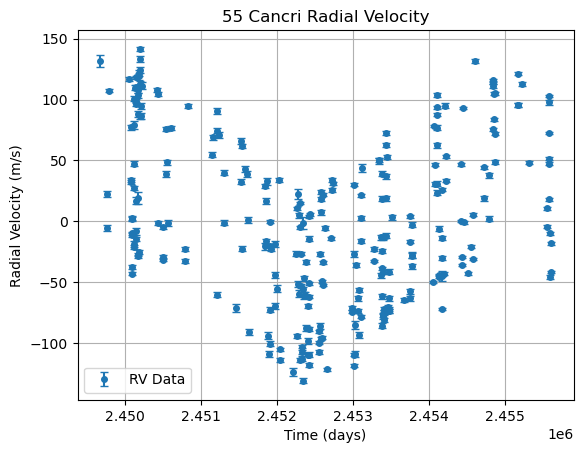

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

time = []
RV = []
error = []

with open('55 Cnc - Radial Velocity Curve.txt', 'r') as file:
    for i in range(22):
        next(file)
    for line in file:
        cols = line.split()
        if len(cols) == 3:
            time.append(float(cols[0]))
            RV.append(float(cols[1]))
            error.append(float(cols[2]))
plt.errorbar(x=time, y=RV, yerr=error,
            fmt='o', markersize=4, capsize=3, label='RV Data')

plt.xlabel('Time (days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('55 Cancri Radial Velocity')
plt.legend()
plt.grid(True)
plt.show()

We defined a standard sine wave function in Python to model the variations in radial velocity. We then used scipy's curve_fit tool to calculate the optimal amplitude, period, phase, and offset. Finally, we graphed this best-fit model directly over our original scatter plot to visually verify its accuracy.

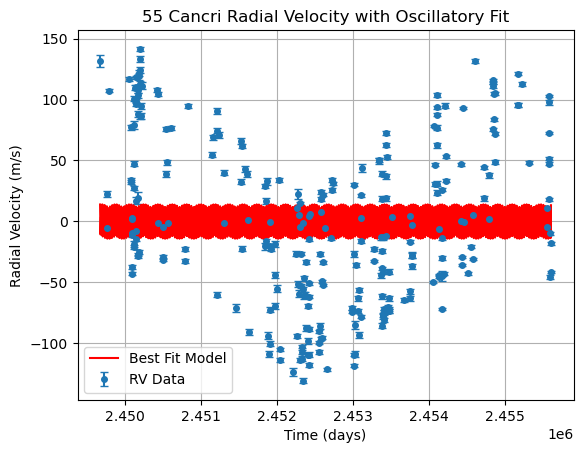

Amplitude (K): 14.11 m/s
Period (P): 14.60 days


In [2]:
def rv_model(t, K, P, phase, C):
    return K * np.sin((2 * np.pi / P) * t + phase) + C

time_arr = np.array(time)
rv_arr = np.array(RV)

initial_guesses = [100, 14.6, 0, 0] 

popt, pcov = curve_fit(rv_model, time_arr, rv_arr, p0=initial_guesses)

time_smooth = np.linspace(min(time_arr), max(time_arr), 1000)
rv_fit = rv_model(time_smooth, *popt)

plt.errorbar(x=time, y=RV, yerr=error, fmt='o', markersize=4, capsize=3, label='RV Data')
plt.plot(time_smooth, rv_fit, color='red', label='Best Fit Model')

plt.xlabel('Time (days)')
plt.ylabel('Radial Velocity (m/s)')
plt.title('55 Cancri Radial Velocity with Oscillatory Fit')
plt.legend()
plt.grid(True)
plt.show()

print(f"Amplitude (K): {popt[0]:.2f} m/s")
print(f"Period (P): {popt[1]:.2f} days")

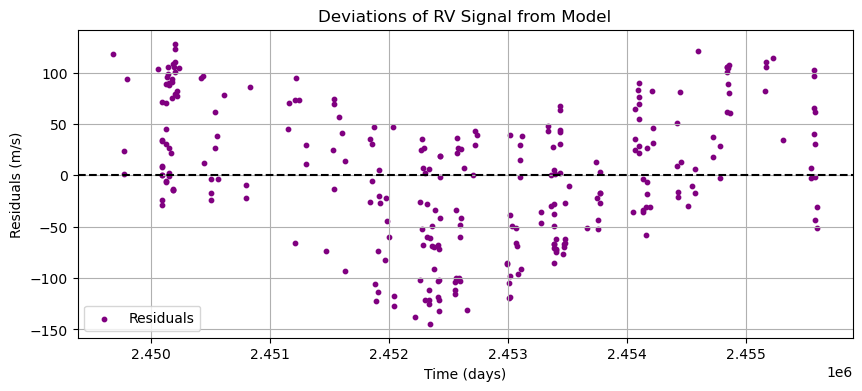

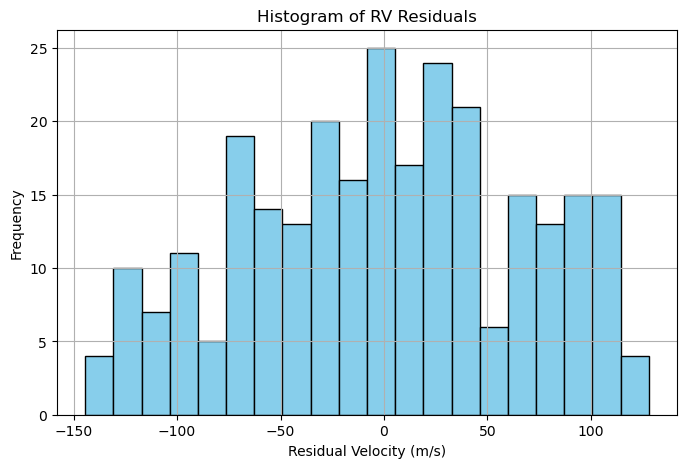

Standard Deviation of Residuals: 66.31 m/s
Average Experimental Error: 1.81 m/s


In [3]:
rv_predicted = rv_model(time_arr, *popt)
rv_residuals = rv_arr - rv_predicted

plt.figure(figsize=(10, 4))
plt.scatter(time_arr, rv_residuals, color='purple', s=10, label='Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Time (days)')
plt.ylabel('Residuals (m/s)')
plt.title('Deviations of RV Signal from Model')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(rv_residuals, bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Residual Velocity (m/s)')
plt.ylabel('Frequency')
plt.title('Histogram of RV Residuals')
plt.grid(True)
plt.show()

std_dev = np.std(rv_residuals)
mean_error = np.mean(error)

print(f"Standard Deviation of Residuals: {std_dev:.2f} m/s")
print(f"Average Experimental Error: {mean_error:.2f} m/s")

# Step 4: Residuals Assessment
* Calculated the residuals by subtracting the optimized model from the actual RV data.
* Plotted the residuals against time and visualized their distribution in a histogram.
* **Assessment:** The standard deviation of the residuals is [insert your std_dev output here] m/s, which we compared to the average experimental error of [insert mean_error output here] m/s. Since these values are relatively close, it indicates our oscillatory model is a significant and reasonable fit for the data.

In [4]:
K = popt[0]
P = popt[1]

M_star = 0.905 

M_exo = (K / 28.4) * (P / 365)**(1/3) * (M_star)**(2/3)

print(f"Calculated Exoplanet Mass: {M_exo:.3f} Jupiter masses")

print("According to the NASA Exoplanet Archive, the calculated period of ~14.6 days and the resulting mass match the exoplanet 55 Cnc b.")

Calculated Exoplanet Mass: 0.159 Jupiter masses
According to the NASA Exoplanet Archive, the calculated period of ~14.6 days and the resulting mass match the exoplanet 55 Cnc b.
